# Лекция 3. Maple → Jupyter — Task 03

Полный перенос `lection(3).pdf` (страницы 1–14): полиномы; пределы и ряды; интегрирование и условия; дифференциальные уравнения; учебные команды пакета `student`.

Запуск: **Restart Kernel → Run All Cells**. Требуются Python 3, SymPy, NumPy, Matplotlib и Jupyter. Notebook самодостаточен.

`prev` хранит результат последней содержательной команды и заменяет Maple `%`. Точные дроби записаны через `sp.Rational`, бесконечность — `sp.oo`. Невычисленные `Limit`, `Derivative`, `Integral`, `Sum` вычисляются отдельно через `.doit()`. Последовательности представлены `tuple`. Каждый обычный `plot` и `showtangent` перенесён двумя соседними кодовыми ячейками; `middlebox` — через Matplotlib.

`restart:` соответствует перезапуску ядра Jupyter. Импорты выполняются один раз в отдельных ячейках ниже.

In [1]:
import sympy as sp

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
from IPython.display import display

In [5]:
from IPython.display import Math

In [6]:
x, y, z, n, a, b, t, h = sp.symbols('x y z n a b t h')
Digits = 10
prev = None
sp.init_printing(use_latex='mathjax')

## Работа с полиномами

**Maple:** `poly:=x+x^2-x^3+1-x^4;`

In [7]:
poly = x+x**2-x**3+1-x**4
prev = poly
display(prev)

   4    3    2        
- x  - x  + x  + x + 1

**Maple:** `poly;`

In [8]:
prev = poly
display(prev)

   4    3    2        
- x  - x  + x  + x + 1

`sort` изменяет порядок членов, но не математическое значение. SymPy обычно автоматически упорядочивает выражения. Короткая функция ниже использует `Poly.terms(order="grlex")`: сначала полная степень, затем порядок переменных. Для показа выбранного порядка используется LaTeX без повторной сортировки.

In [9]:
def sort_poly(expression, *variables):
    terms = sp.Poly(expression, *variables).terms(order="grlex")
    return sp.Add(*(coefficient * sp.Mul(*(v**power for v, power in zip(variables, powers)))
                    for powers, coefficient in terms), evaluate=False)

**Maple:** `sort(poly);`

In [10]:
poly = sort_poly(poly, x)
prev = poly
display(Math(sp.latex(prev, order="none")))

<IPython.core.display.Math object>

**Maple:** `poly;`

In [11]:
prev = poly
display(prev)

   4    3    2        
- x  - x  + x  + x + 1

**Maple:** `mul_var_poly:=y^3+x^2*y^2+x^3;`

In [12]:
mul_var_poly = y**3+x**2*y**2+x**3
prev = mul_var_poly
display(prev)

 3    2  2    3
x  + x ⋅y  + y 

**Maple:** `sort(mul_var_poly,[x,y]);`

In [13]:
mul_var_poly = sort_poly(mul_var_poly, x, y)
prev = mul_var_poly
display(Math(sp.latex(prev, order="none")))

<IPython.core.display.Math object>

**Maple:** `Mul_var_poly:=x^2*y^2+y^5+x^3;`

In [14]:
Mul_var_poly = x**2*y**2+y**5+x**3
prev = Mul_var_poly
display(prev)

 3    2  2    5
x  + x ⋅y  + y 

**Maple:** `sort(Mul_var_poly,[x,y]);`

In [15]:
Mul_var_poly = sort_poly(Mul_var_poly, x, y)
prev = Mul_var_poly
display(Math(sp.latex(prev, order="none")))

<IPython.core.display.Math object>

**Maple:** `sort(Mul_var_poly,[y,x]);`

In [16]:
Mul_var_poly = sort_poly(Mul_var_poly, y, x)
prev = Mul_var_poly
display(Math(sp.latex(prev, order="none")))

<IPython.core.display.Math object>

**Maple:** `big_poly:=x*y+z*x*y+y*x^2-z*y*x^2+x+z*x;`

In [17]:
big_poly = x*y+z*x*y+y*x**2-z*y*x**2+x+z*x
prev = big_poly
display(prev)

   2        2                          
- x ⋅y⋅z + x ⋅y + x⋅y⋅z + x⋅y + x⋅z + x

**Maple:** `collect(big_poly,x);`

In [18]:
prev = sp.collect(big_poly, x)
display(prev)

 2                                 
x ⋅(-y⋅z + y) + x⋅(y⋅z + y + z + 1)

**Maple:** `collect(big_poly,z);`

In [19]:
prev = sp.collect(big_poly, z)
display(prev)

 2                 ⎛   2            ⎞
x ⋅y + x⋅y + x + z⋅⎝- x ⋅y + x⋅y + x⎠

**Maple:** `r:=rem(x^3+x+1,x^2+x+1,x);`

In [20]:
r = sp.rem(x**3+x+1, x**2+x+1, x)
prev = r
display(prev)

x + 2

**Maple:** `q:=quo(x^3+x+1,x^2+x+1,x);`

In [21]:
q = sp.quo(x**3+x+1, x**2+x+1, x)
prev = q
display(prev)

x - 1

**Maple:** `collect((x^2+x+1)*q+r,x);`

Проверка восстановления делимого из частного и остатка.

In [22]:
prev = sp.collect(sp.expand((x**2+x+1)*q+r), x)
display(prev)

 3        
x  + x + 1

**Maple:** `divide(x^3-y^3,x-y);`

Maple без выходного параметра возвращает логический признак делимости; проверяем нулевой остаток.

In [23]:
prev = sp.rem(x**3-y**3, x-y, x) == 0
display(prev)

True

**Maple:** `rem(x^3-y^3,x-y,x);`

In [24]:
prev = sp.rem(x**3-y**3, x-y, x)
display(prev)

0

**Maple:** `poly:=x^2+3*x-4;`

In [25]:
poly = x**2+3*x-4
prev = poly
display(prev)

 2          
x  + 3⋅x - 4

**Maple:** `subs(x=2,poly);`

In [26]:
prev = poly.subs(x,2)
display(prev)

6

**Maple:** `eval(poly,x=2);`

Для такой подстановки `eval` и `subs` имеют один аналог.

In [27]:
prev = poly.subs(x,2)
display(prev)

6

**Maple:** `mul_var_poly:=y^2*x-2*y+x^2*y+1;`

In [28]:
mul_var_poly = y**2*x-2*y+x**2*y+1
prev = mul_var_poly
display(prev)

 2        2          
x ⋅y + x⋅y  - 2⋅y + 1

**Maple:** `subs({y=1,x=-1},mul_var_poly);`

In [29]:
prev = mul_var_poly.subs({y:1,x:-1}, simultaneous=True)
display(prev)

-1

**Maple:** `poly:=3*z^3-z^2+2*z-3*z+1;`

In [30]:
poly = 3*z**3-z**2+2*z-3*z+1
prev = poly
display(prev)

   3    2        
3⋅z  - z  - z + 1

**Maple:** `coeff(poly,z^2);`

In [31]:
prev = sp.Poly(poly,z).coeff_monomial(z**2)
display(prev)

-1

**Maple:** `degree(poly);`

In [32]:
prev = sp.Poly(poly,z).total_degree()
display(prev)

3

**Maple:** `poly:=(x+2)*x^2-x^2*(1+n);`

In [33]:
poly = (x+2)*x**2-x**2*(1+n)
prev = poly
display(prev)

   2            2        
- x ⋅(n + 1) + x ⋅(x + 2)

**Maple:** `coeff(poly,x^2);`

`Poly` раскрывает произведения для корректного извлечения коэффициента.

In [34]:
prev = sp.Poly(poly,x).coeff_monomial(x**2)
display(prev)

1 - n

**Maple:** `new_poly:=collect(poly,x);`

In [35]:
new_poly = sp.collect(sp.expand(poly),x)
prev = new_poly
display(prev)

 3    2        
x  + x ⋅(1 - n)

**Maple:** `coeff(new_poly,x^2);`

In [36]:
prev = sp.Poly(new_poly,x).coeff_monomial(x**2)
display(prev)

1 - n

**Maple:** `poly1:=x^6-x^5-9*x^4+x^3+20*x^2+12*x;`

In [37]:
poly1 = x**6-x**5-9*x**4+x**3+20*x**2+12*x
prev = poly1
display(prev)

 6    5      4    3       2       
x  - x  - 9⋅x  + x  + 20⋅x  + 12⋅x

**Maple:** `factor(poly1);`

In [38]:
prev = sp.factor(poly1)
display(prev)

                         2        
x⋅(x - 3)⋅(x - 2)⋅(x + 1) ⋅(x + 2)

**Maple:** `poly2:=x+3;`

In [39]:
poly2 = x+3
prev = poly2
display(prev)

x + 3

**Maple:** `poly3:=expand(poly2^6);`

In [40]:
poly3 = sp.expand(poly2**6)
prev = poly3
display(prev)

 6       5        4        3         2               
x  + 18⋅x  + 135⋅x  + 540⋅x  + 1215⋅x  + 1458⋅x + 729

**Maple:** `factor(poly3);`

In [41]:
prev = sp.factor(poly3)
display(prev)

       6
(x + 3) 

**Maple:** `solve({poly3=0},{x});`

`solve` SymPy выдаёт уникальные корни. В PDF корень −3 повторяется шесть раз; `Poly.all_roots()` сохраняет кратности и выводит шесть равенств.

In [42]:
prev = tuple(sp.Eq(x, root) for root in sp.Poly(poly3,x).all_roots())
display(prev)

(x = -3, x = -3, x = -3, x = -3, x = -3, x = -3)

**Maple:** `factor(x^3+y^3);`

In [43]:
prev = sp.factor(x**3+y**3)
display(prev)

        ⎛ 2          2⎞
(x + y)⋅⎝x  - x⋅y + y ⎠

## Пределы и ряды

**Maple:** `f:=x->(x^2-2*x+1)/(x^4+3*x^3-7*x^2+x+2);`

In [44]:
f = sp.Lambda(x,(x**2-2*x+1)/(x**4+3*x**3-7*x**2+x+2))
prev = f
display(prev)

           2                
          x  - 2⋅x + 1      
x ↦ ────────────────────────
     4      3      2        
    x  + 3⋅x  - 7⋅x  + x + 2

**Maple:** `Limit(f(x),x=1);`

In [45]:
prev = sp.Limit(f(x),x,1,dir="+-")
display(prev)

    ⎛       2                ⎞
    ⎜      x  - 2⋅x + 1      ⎟
lim ⎜────────────────────────⎟
x─→1⎜ 4      3      2        ⎟
    ⎝x  + 3⋅x  - 7⋅x  + x + 2⎠

**Maple:** `value(%);`

In [46]:
prev = prev.doit()
display(prev)

1/8

**Maple:** `Limit(tan(x),x=Pi/2,left);`

In [47]:
prev = sp.Limit(sp.tan(x),x,sp.pi/2,dir="-")
display(prev)

 lim tan(x)
   π       
x─→─⁻      
   2       

**Maple:** `value(%);`

In [48]:
prev = prev.doit()
display(prev)

∞

**Maple:** `Limit(tan(x),x=Pi/2,left)=limit(tan(x),x=Pi/2,left);`

In [49]:
prev = sp.Eq(sp.Limit(sp.tan(x),x,sp.pi/2,dir="-"), sp.limit(sp.tan(x),x,sp.pi/2,dir="-"), evaluate=False)
display(prev)

 lim tan(x) = ∞
   π           
x─→─⁻          
   2           

**Maple:** `Limit(tan(x),x=Pi/2,right);`

In [50]:
prev = sp.Limit(sp.tan(x),x,sp.pi/2,dir="+")
display(prev)

 lim tan(x)
   π       
x─→─⁺      
   2       

**Maple:** `value(%);`

In [51]:
prev = prev.doit()
display(prev)

-∞

**Maple:** `f:=x->sin(4*x)*cos(x);`

In [52]:
f = sp.Lambda(x,sp.sin(4*x)*sp.cos(x))
prev = f
display(prev)

x ↦ sin(4⋅x)⋅cos(x)

**Maple:** `fs:=series(f(x),x=0);`

Maple по умолчанию использует Order=6, но в PDF за счёт нечётности записан остаток O(x⁷). Явный порядок 7 в SymPy воспроизводит эту запись.

In [53]:
fs = sp.series(f(x),x,0,7)
prev = fs
display(prev)

          3        5        
      38⋅x    421⋅x     ⎛ 7⎞
4⋅x - ───── + ────── + O⎝x ⎠
        3       30          

**Maple:** `p:=convert(fs,polynom);`

Удаляется только остаточный член.

In [54]:
p = fs.removeO()
prev = p
display(prev)

     5       3      
421⋅x    38⋅x       
────── - ───── + 4⋅x
  30       3        

**Maple:** `plot({f(x),p},x=-1..1,-2..2,title=`sin(4x)cos(x) -- Series`);`

Две соседние ячейки строят одинаковые выражения: сначала SymPy, затем Matplotlib.

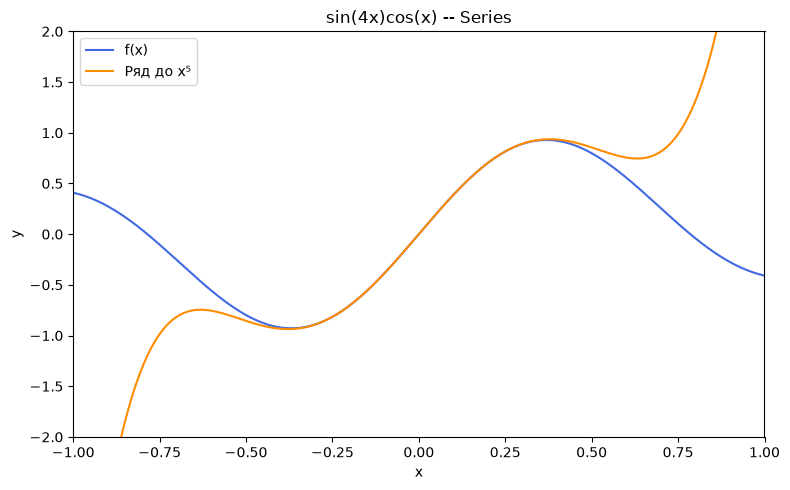

In [55]:
plot_expressions = (f(x),p)
plot_labels = ['f(x)', 'Ряд до x⁵']
plot_title = 'sin(4x)cos(x) -- Series'
prev = sp.plot(*plot_expressions, (x, -1, 1),
    xlim=(-1, 1), ylim=(-2, 2), title=plot_title, legend=True,
    xlabel="x", ylabel="y", axis_center=None, size=(8, 5), show=False)
for series, label, color in zip(prev, plot_labels, ["royalblue", "darkorange"]):
    series.label = label
    series.line_color = color
prev.process_series()
for spine in prev.ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_position(("outward", 0))
prev.ax.set_xlabel("x", loc="center")
prev.ax.set_ylabel("y", loc="center")
prev.fig.tight_layout()
display(prev.fig)
plt.close(prev.fig)

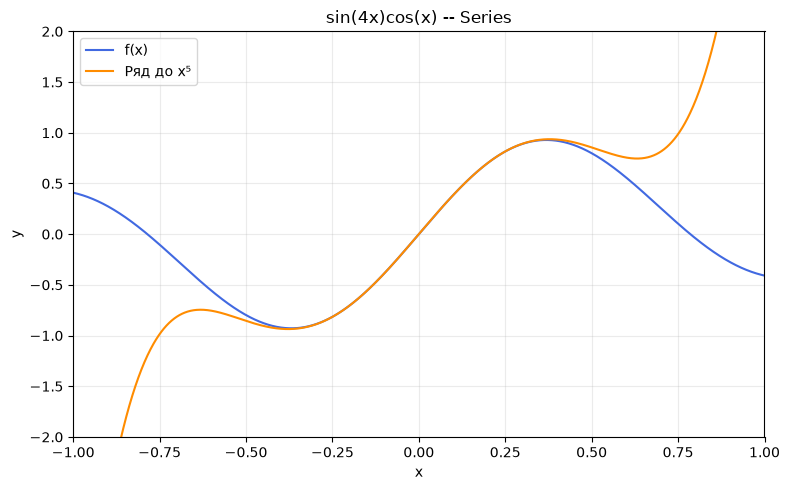

In [56]:
grid = np.linspace(-1, 1, 1601)
fig = plt.figure(figsize=(8, 5))
for expression, label, color in zip(plot_expressions, plot_labels, ["royalblue", "darkorange"]):
    numerical = sp.lambdify(x, expression, "numpy")
    plt.plot(grid, np.broadcast_to(numerical(grid), grid.shape), label=label, color=color)
plt.xlim(-1, 1)
plt.ylim(-2, 2)
plt.xlabel("x")
plt.ylabel("y")
plt.title(plot_title)
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
prev = fig
plt.show()

**Maple:** `Order;` → `6`; `Order:=12;`

Глобальная переменная `Order` не эмулируется. Порядок задаётся явно в следующем `series`. Как в PDF, остаток нечётного ряда будет O(x¹³).

**Maple:** `fs:=series(f(x),x=0);`

In [57]:
fs = sp.series(f(x),x,0,13)
prev = fs
display(prev)

          3        5          7           9            11         
      38⋅x    421⋅x    10039⋅x    246601⋅x    6125659⋅x      ⎛ 13⎞
4⋅x - ───── + ────── - ──────── + ───────── - ─────────── + O⎝x  ⎠
        3       30       1260       90720       9979200           

**Maple:** `p:=convert(fs,polynom);`

In [58]:
p = fs.removeO()
prev = p
display(prev)

           11           9          7        5       3      
  6125659⋅x     246601⋅x    10039⋅x    421⋅x    38⋅x       
- ─────────── + ───────── - ──────── + ────── - ───── + 4⋅x
    9979200       90720       1260       30       3        

**Maple:** `plot({f(x),p},x=-1..1,-2..2,title="sin(4x)cos(x) -- Series  Order 12",titlefont=[TIMES,BOLD,12]);`

Две соседние ячейки строят одинаковые выражения: сначала SymPy, затем Matplotlib.

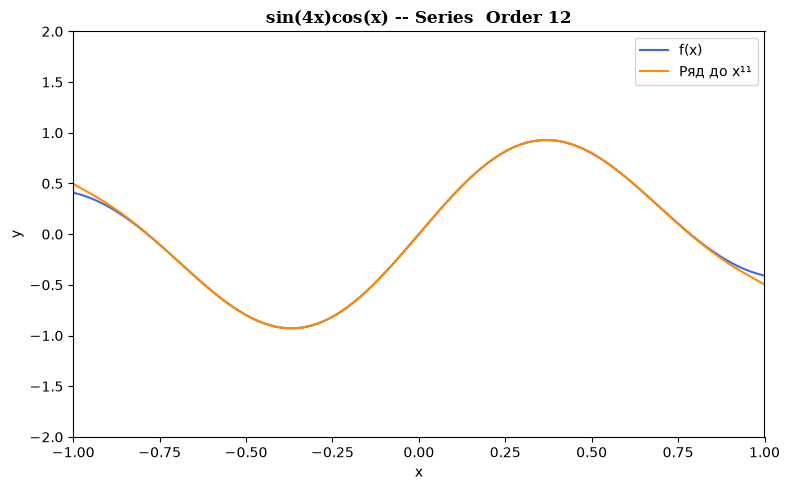

In [59]:
plot_expressions = (f(x),p)
plot_labels = ['f(x)', 'Ряд до x¹¹']
plot_title = 'sin(4x)cos(x) -- Series  Order 12'
prev = sp.plot(*plot_expressions, (x, -1, 1),
    xlim=(-1, 1), ylim=(-2, 2), title=plot_title, legend=True,
    xlabel="x", ylabel="y", axis_center=None, size=(8, 5), show=False)
for series, label, color in zip(prev, plot_labels, ["royalblue", "darkorange"]):
    series.label = label
    series.line_color = color
prev.process_series()
for spine in prev.ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_position(("outward", 0))
prev.ax.set_xlabel("x", loc="center")
prev.ax.set_ylabel("y", loc="center")
prev.ax.set_title(plot_title, fontfamily='serif', fontweight='bold', fontsize=12)
prev.fig.tight_layout()
display(prev.fig)
plt.close(prev.fig)

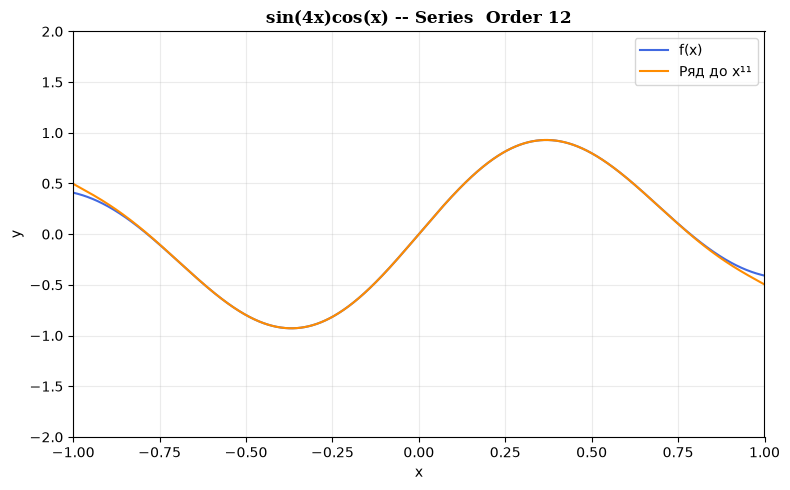

In [60]:
grid = np.linspace(-1, 1, 1601)
fig = plt.figure(figsize=(8, 5))
for expression, label, color in zip(plot_expressions, plot_labels, ["royalblue", "darkorange"]):
    numerical = sp.lambdify(x, expression, "numpy")
    plt.plot(grid, np.broadcast_to(numerical(grid), grid.shape), label=label, color=color)
plt.xlim(-1, 1)
plt.ylim(-2, 2)
plt.xlabel("x")
plt.ylabel("y")
plt.title(plot_title, fontfamily="serif", fontweight="bold", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
prev = fig
plt.show()

## Интегрирование, дополнительные условия

**Maple:** `f:=x->x*sin(a*x)+b*x^2;`

In [61]:
f = sp.Lambda(x,x*sp.sin(a*x)+b*x**2)
prev = f
display(prev)

       2             
x ↦ b⋅x  + x⋅sin(a⋅x)

**Maple:** `Diff(f(x),x);`

In [62]:
prev = sp.Derivative(f(x),x,evaluate=False)
display(prev)

∂ ⎛   2             ⎞
──⎝b⋅x  + x⋅sin(a⋅x)⎠
∂x                   

**Maple:** `df:=value(%);`

In [63]:
df = prev.doit()
prev = df
display(prev)

a⋅x⋅cos(a⋅x) + 2⋅b⋅x + sin(a⋅x)

**Maple:** `Int(df,x);`

In [64]:
prev = sp.Integral(df,x)
display(prev)

⌠                                     
⎮ (a⋅x⋅cos(a⋅x) + 2⋅b⋅x + sin(a⋅x)) dx
⌡                                     

**Maple:** `value(%);`

Используем общий вид первообразной, как Maple. Промежуточная запись содержит деление на a; после упрощения устранимая особенность при a=0 исчезает.

In [65]:
prev = prev.doit(conds="none")
display(prev)

  ⎛x⋅sin(a⋅x)   cos(a⋅x)⎞      2   cos(a⋅x)
a⋅⎜────────── + ────────⎟ + b⋅x  - ────────
  ⎜    a            2   ⎟             a    
  ⎝                a    ⎠                  

**Maple:** `simplify(%);`

In [66]:
prev = sp.simplify(prev)
display(prev)

x⋅(b⋅x + sin(a⋅x))

**Maple:** `Int(df,x=1..2);`

In [67]:
prev = sp.Integral(df,(x,1,2))
display(prev)

2                                     
⌠                                     
⎮ (a⋅x⋅cos(a⋅x) + 2⋅b⋅x + sin(a⋅x)) dx
⌡                                     
1                                     

**Maple:** `value(%);`

После сокращения результат корректен также при a=0; интеграл по конечному отрезку не требует условия a>0.

In [68]:
prev = sp.simplify(prev.doit(conds="none"))
display(prev)

3⋅b - sin(a) + 2⋅sin(2⋅a)

**Maple:** `Int(exp(-x^2),x);`

In [69]:
prev = sp.Integral(sp.exp(-x**2),x)
display(prev)

⌠        
⎮    2   
⎮  -x    
⎮ ℯ    dx
⌡        

**Maple:** `value(%);`

In [70]:
prev = prev.doit()
display(prev)

√π⋅erf(x)
─────────
    2    

**Maple:** `g:=t->exp(-a*t)*ln(t);`

In [71]:
g = sp.Lambda(t,sp.exp(-a*t)*sp.log(t))
prev = g
display(prev)

     -a⋅t       
t ↦ ℯ    ⋅log(t)

**Maple:** `Int(g(t),t=0..infinity);`

In [72]:
prev = sp.Integral(g(t),(t,0,sp.oo))
display(prev)

∞                
⌠                
⎮  -a⋅t          
⎮ ℯ    ⋅log(t) dt
⌡                
0                

**Maple:** `value(%);`

Без условий на a SymPy может вернуть Piecewise: вычисленную ветвь при условии сходимости и невычисленный интеграл в остальных случаях.

In [73]:
prev = sp.simplify(prev.doit())
display(prev)

⎧   -log(a) - γ                    π
⎪   ───────────     for │arg(a)│ < ─
⎪        a                         2
⎪                                   
⎪∞                                  
⎨⌠                                  
⎪⎮  -a⋅t                            
⎪⎮ ℯ    ⋅log(t) dt     otherwise    
⎪⌡                                  
⎪0                                  
⎩                                   

**Maple:** `assume(a>0);`

В SymPy свойства символа неизменяемы. Создаём отдельный положительный символ `a_positive` и явно подставляем его в интеграл; исходный `a` сохраняем без предположений.

In [74]:
a_positive = sp.Symbol("a", positive=True)

**Maple:** `ans:=Int(g(t),t=0..infinity);`

In [75]:
ans = sp.Integral(g(t).subs(a,a_positive),(t,0,sp.oo))
prev = ans
display(prev)

∞                
⌠                
⎮  -a⋅t          
⎮ ℯ    ⋅log(t) dt
⌡                
0                

**Maple:** `value(%);`

In [76]:
prev = sp.simplify(prev.doit())
display(prev)

-log(a) - γ
───────────
     a     

**Maple:** `about(a);`

Словарь предположений показывает, в частности, positive=True и real=True.

In [77]:
prev = a_positive.assumptions0
display(prev)

{'commutative': True,
 'complex': True,
 'extended_negative': False,
 'extended_nonnegative': True,
 'extended_nonpositive': False,
 'extended_nonzero': True,
 'extended_positive': True,
 'extended_real': True,
 'finite': True,
 'hermitian': True,
 'imaginary': False,
 'infinite': False,
 'negative': False,
 'nonnegative': True,
 'nonpositive': False,
 'nonzero': True,
 'positive': True,
 'real': True,
 'zero': False}

**Maple:** `evalf(gamma);`

In [78]:
prev = sp.N(sp.EulerGamma,Digits)
display(prev)

0.5772156649

**Maple:** `ans:=subs(a='a',ans);`

Возвращаем интеграл к исходному символу без условия положительности.

In [79]:
ans = ans.subs(a_positive,a)
prev = ans
display(prev)

∞                
⌠                
⎮  -a⋅t          
⎮ ℯ    ⋅log(t) dt
⌡                
0                

**Maple:** `a:='a';`

В этой реализации `a` не менялся: положительный символ хранился отдельно. Снимать глобальное предположение не требуется.

## Дифференциальные уравнения

В этой части `y` и `z` — неизвестные функции. Ранее одноимённые символы использовались только в полиномах.

In [80]:
y = sp.Function("y")
z = sp.Function("z")
y_unknown = y

**Maple:** `ode1:={diff(y(t),t,t)+5*diff(y(t),t)+6*y(t)=0};`

In [81]:
ode1 = sp.Eq(sp.diff(y(t),t,2)+5*sp.diff(y(t),t)+6*y(t),0)
prev = ode1
display(prev)

                       2           
           d          d            
6⋅y(t) + 5⋅──(y(t)) + ───(y(t)) = 0
           dt           2          
                      dt           

**Maple:** `ic:={y(0)=0,D(y)(0)=1};`

Начальные условия для dsolve представлены словарём.

In [82]:
ic = {y(0):0, sp.diff(y(t),t).subs(t,0):1}
prev = ic
display(prev)

⎧         ⎛d       ⎞│      ⎫
⎨y(0): 0, ⎜──(y(t))⎟│   : 1⎬
⎩         ⎝dt      ⎠│t=0   ⎭

**Maple:** `soln:=dsolve(ode1 union ic,{y(t)});`

In [83]:
soln = sp.dsolve(ode1,y(t),ics=ic)
prev = soln
display(prev)

       ⎛     -t⎞  -2⋅t
y(t) = ⎝1 - ℯ  ⎠⋅ℯ    

**Maple:** `subs(soln,y(t));`

In [84]:
prev = y(t).subs(soln.lhs,soln.rhs)
display(prev)

⎛     -t⎞  -2⋅t
⎝1 - ℯ  ⎠⋅ℯ    

**Maple:** `y1:=unapply(%,t);`

In [85]:
y1 = sp.Lambda(t,prev)
prev = y1
display(prev)

    ⎛     -t⎞  -2⋅t
t ↦ ⎝1 - ℯ  ⎠⋅ℯ    

**Maple:** `y1(a);`

In [86]:
prev = y1(a)
display(prev)

⎛     -a⎞  -2⋅a
⎝1 - ℯ  ⎠⋅ℯ    

**Maple:** `subs(y=y1,ode1);`

Подстановка сохраняет производные; следующая команда их вычисляет.

In [87]:
prev = sp.Eq(ode1.lhs.subs(y(t),y1(t)),ode1.rhs,evaluate=False)
display(prev)

                                             2                      
  ⎛     -t⎞  -2⋅t     d ⎛⎛     -t⎞  -2⋅t⎞   d  ⎛⎛     -t⎞  -2⋅t⎞    
6⋅⎝1 - ℯ  ⎠⋅ℯ     + 5⋅──⎝⎝1 - ℯ  ⎠⋅ℯ    ⎠ + ───⎝⎝1 - ℯ  ⎠⋅ℯ    ⎠ = 0
                      dt                      2                     
                                            dt                      

**Maple:** `eval(%);`

In [88]:
prev = sp.Eq(prev.lhs.doit(),prev.rhs.doit(),evaluate=False)
display(prev)

    ⎛     -t⎞  -2⋅t   ⎛       -t⎞  -2⋅t      -3⋅t    
- 4⋅⎝1 - ℯ  ⎠⋅ℯ     + ⎝4 - 9⋅ℯ  ⎠⋅ℯ     + 5⋅ℯ     = 0

**Maple:** `subs(y=y1,ic);`

In [89]:
prev = tuple(sp.Eq(lhs.subs(y,y1),rhs,evaluate=False) for lhs,rhs in ic.items())
display(prev)

⎛       ⎛d ⎛⎛     -t⎞  -2⋅t⎞⎞│       ⎞
⎜0 = 0, ⎜──⎝⎝1 - ℯ  ⎠⋅ℯ    ⎠⎟│    = 1⎟
⎝       ⎝dt                 ⎠│t=0    ⎠

**Maple:** `eval(%);`

In [90]:
prev = tuple(sp.Eq(eq.lhs.doit(),eq.rhs.doit(),evaluate=False) for eq in prev)
display(prev)

(0 = 0, 1 = 1)

**Maple:** `y:=unapply(subs(soln,y(t)),t);`

In [91]:
y = sp.Lambda(t,y(t).subs(soln.lhs,soln.rhs))
prev = y
display(prev)

    ⎛     -t⎞  -2⋅t
t ↦ ⎝1 - ℯ  ⎠⋅ℯ    

**Maple:** `ode1;`

Maple повторно раскрывает присвоенное имя. В Python сохранённые выражения не меняются автоматически, поэтому подстановка выполняется явно.

In [92]:
prev = sp.Eq(ode1.lhs.subs(y_unknown,y).doit(),ode1.rhs,evaluate=False)
display(prev)

    ⎛     -t⎞  -2⋅t   ⎛       -t⎞  -2⋅t      -3⋅t    
- 4⋅⎝1 - ℯ  ⎠⋅ℯ     + ⎝4 - 9⋅ℯ  ⎠⋅ℯ     + 5⋅ℯ     = 0

**Maple:** `ic;`

In [93]:
prev = tuple(sp.Eq(lhs.subs(y_unknown,y).doit(),rhs,evaluate=False) for lhs,rhs in ic.items())
display(prev)

(0 = 0, 1 = 1)

**Maple:** `y:='y';`

In [94]:
y = sp.Function("y")
prev = y
display(prev)

y

### Уравнение четвёртого порядка с обобщёнными функциями

**Maple:** `ode2:=10^6*diff(y(x),x,x,x,x)=Dirac(x-2)-Dirac(x-4);`

In [95]:
ode2 = sp.Eq(10**6*sp.diff(y(x),x,4),sp.DiracDelta(x-2)-sp.DiracDelta(x-4))
prev = ode2
display(prev)

         4                              
        d                               
1000000⋅───(y(x)) = -δ(x - 4) + δ(x - 2)
          4                             
        dx                              

**Maple:** `iv:=y(0)=0,D(D(y))(0)=0;`

In [96]:
iv = (sp.Eq(y(0),0), sp.Eq(sp.diff(y(x),x,2).subs(x,0),0))
prev = iv
display(prev)

⎛          ⎛ 2       ⎞│       ⎞
⎜          ⎜d        ⎟│       ⎟
⎜y(0) = 0, ⎜───(y(x))⎟│    = 0⎟
⎜          ⎜  2      ⎟│       ⎟
⎝          ⎝dx       ⎠│x=0    ⎠

**Maple:** `bc:=y(5)=0,D(D(y))(5)=0;`

In [97]:
bc = (sp.Eq(y(5),0), sp.Eq(sp.diff(y(x),x,2).subs(x,5),0))
prev = bc
display(prev)

⎛          ⎛ 2       ⎞│       ⎞
⎜          ⎜d        ⎟│       ⎟
⎜y(5) = 0, ⎜───(y(x))⎟│    = 0⎟
⎜          ⎜  2      ⎟│       ⎟
⎝          ⎝dx       ⎠│x=5    ⎠

**Maple:** `soln:=dsolve({ode2,bc,iv},{y(x)});`

In [98]:
soln = sp.dsolve(ode2,y(x),ics={eq.lhs:eq.rhs for eq in iv+bc})
prev = soln
display(prev)
bvp_solution = soln

        3 ⎛  θ(x - 4)   θ(x - 2)      1    ⎞    2 ⎛θ(x - 4)   θ(x - 2)⎞     ⎛  ↪
y(x) = x ⋅⎜- ──────── + ──────── - ────────⎟ + x ⋅⎜──────── - ────────⎟ + x⋅⎜- ↪
          ⎝  6000000    6000000    15000000⎠      ⎝ 500000    1000000 ⎠     ⎝  ↪

↪  θ(x - 4)   θ(x - 2)      1   ⎞   θ(x - 4)   θ(x - 2)
↪  ──────── + ──────── + ───────⎟ + ──────── - ────────
↪   125000     500000    1250000⎠    93750      750000 

**Maple:** `subs(soln,y(x)):`

In [99]:
prev = y(x).subs(soln.lhs,soln.rhs)

**Maple:** `y:=unapply(%,x);`

In [100]:
y = sp.Lambda(x,prev)
prev = y
display(prev)

     3 ⎛  θ(x - 4)   θ(x - 2)      1    ⎞    2 ⎛θ(x - 4)   θ(x - 2)⎞     ⎛  θ( ↪
x ↦ x ⋅⎜- ──────── + ──────── - ────────⎟ + x ⋅⎜──────── - ────────⎟ + x⋅⎜- ── ↪
       ⎝  6000000    6000000    15000000⎠      ⎝ 500000    1000000 ⎠     ⎝   1 ↪

↪ x - 4)   θ(x - 2)      1   ⎞   θ(x - 4)   θ(x - 2)
↪ ────── + ──────── + ───────⎟ + ──────── - ────────
↪ 25000     500000    1250000⎠    93750      750000 

**Maple:** `ode2;`

In [101]:
prev = sp.Eq(ode2.lhs.subs(y_unknown,y).doit(),ode2.rhs,evaluate=False)
display(prev)

   3 ⎛ (3)            (3)        ⎞       2 ⎛ (2)            (2)        ⎞       ↪
- x ⋅⎝δ    (x - 4) - δ    (x - 2)⎠ - 12⋅x ⋅⎝δ    (x - 4) - δ    (x - 2)⎠ + 6⋅x ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                                               ↪

↪ 2 ⎛   (3)            (3)        ⎞        ⎛ (1)            (1)        ⎞       ↪
↪  ⋅⎝2⋅δ    (x - 4) - δ    (x - 2)⎠ - 36⋅x⋅⎝δ    (x - 4) - δ    (x - 2)⎠ + 48⋅ ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                                                                              ↪

↪   ⎛   (2)            (2)        ⎞        ⎛   (3)            (3)        ⎞     ↪
↪ x⋅⎝2⋅δ    (x - 4) - δ    (x - 2)⎠ - 12⋅x⋅⎝4⋅δ    (x - 4) - δ    (x - 2)⎠ - 2 ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                            6                                                 ↪

↪                        

**Maple:** `simplify(%);`

Обычный `simplify` SymPy не всегда сокращает произведения полиномов с производными дельта-функции. Для проверки предыдущего равенства применяем тождество распределений

$$p(x)\delta^{(m)}(x-c)=\sum_{k=0}^m(-1)^k\binom{m}{k}p^{(k)}(c)\delta^{(m-k)}(x-c).$$

Функция ниже обрабатывает встречающиеся здесь дельта-функции с аргументом `x-c`. Проверяется вычисленное решение, ответ не подставляется вручную.

In [102]:
def simplify_deltas(expression, variable):
    result = 0
    for term in sp.Add.make_args(sp.expand(expression)):
        deltas = term.atoms(sp.DiracDelta)
        if not deltas:
            result += term
            continue
        delta, = deltas
        argument = delta.args[0]
        assert sp.diff(argument, variable) == 1
        center = sp.solve(argument, variable)[0]
        order = int(delta.args[1]) if len(delta.args) > 1 else 0
        coefficient = sp.cancel(term / delta)
        result += sum((-1)**k * sp.binomial(order,k)
                      * sp.diff(coefficient,variable,k).subs(variable,center)
                      * sp.DiracDelta(variable-center,order-k)
                      for k in range(order+1))
    return sp.simplify(result)

prev = sp.Eq(simplify_deltas(prev.lhs,x), simplify_deltas(prev.rhs,x), evaluate=False)
display(prev)
assert sp.simplify(prev.lhs-prev.rhs) == 0

-δ(x - 4) + δ(x - 2) = -δ(x - 4) + δ(x - 2)

**Maple:** `iv;`

In [103]:
prev = tuple(sp.Eq(eq.lhs.subs(y_unknown,y).doit(),eq.rhs,evaluate=False) for eq in iv)
display(prev)

(0 = 0, 0 = 0)

**Maple:** `bc;`

In [104]:
prev = tuple(sp.Eq(eq.lhs.subs(y_unknown,y).doit(),eq.rhs,evaluate=False) for eq in bc)
display(prev)

(0 = 0, 0 = 0)

**Maple:** `plot(y(x),x=-1..6,axes=BOXED,title=`Solution to a a 4th Order BVP`);`

Две соседние ячейки строят одинаковые выражения: сначала SymPy, затем Matplotlib.

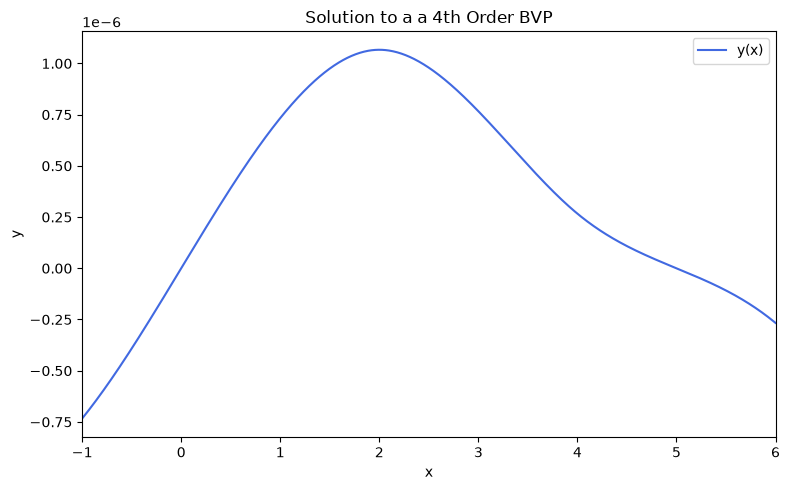

In [105]:
plot_expressions = (y(x),)
plot_labels = ['y(x)']
plot_title = 'Solution to a a 4th Order BVP'
prev = sp.plot(*plot_expressions, (x, -1, 6),
    xlim=(-1, 6), title=plot_title, legend=True,
    xlabel="x", ylabel="y", axis_center=None, size=(8, 5), show=False)
for series, label, color in zip(prev, plot_labels, ["royalblue", "darkorange"]):
    series.label = label
    series.line_color = color
prev.process_series()
for spine in prev.ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_position(("outward", 0))
prev.ax.set_xlabel("x", loc="center")
prev.ax.set_ylabel("y", loc="center")
prev.fig.tight_layout()
display(prev.fig)
plt.close(prev.fig)

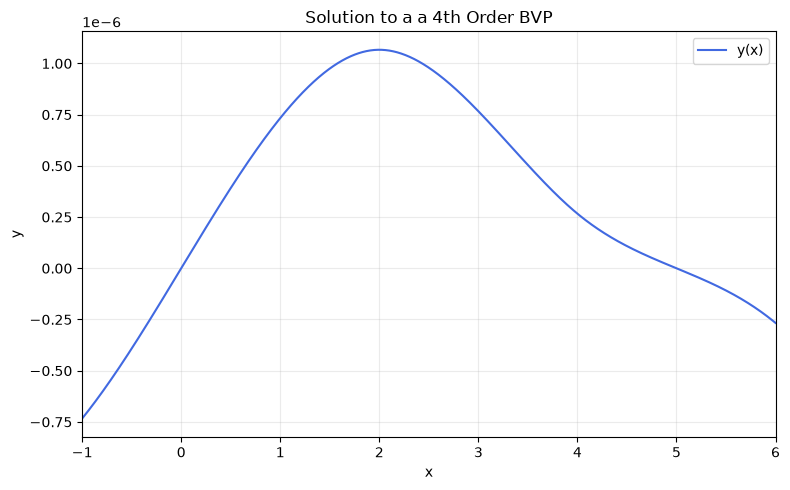

In [106]:
grid = np.linspace(-1, 6, 1601)
fig = plt.figure(figsize=(8, 5))
for expression, label, color in zip(plot_expressions, plot_labels, ["royalblue", "darkorange"]):
    numerical = sp.lambdify(x, expression, "numpy")
    plt.plot(grid, np.broadcast_to(numerical(grid), grid.shape), label=label, color=color)
plt.xlim(-1, 6)
plt.xlabel("x")
plt.ylabel("y")
plt.title(plot_title)
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
prev = fig
plt.show()

**Maple:** `y:='y';`

In [107]:
y = sp.Function("y")
prev = y
display(prev)

y

### Система дифференциальных уравнений

**Maple:** `de_sys:={diff(y(x),x,x)=z(x),diff(z(x),x,x)=y(x)};`

In [108]:
de_sys = [sp.Eq(sp.diff(y(x),x,2),z(x)), sp.Eq(sp.diff(z(x),x,2),y(x))]
prev = de_sys
display(prev)

⎡ 2                 2              ⎤
⎢d                 d               ⎥
⎢───(y(x)) = z(x), ───(z(x)) = y(x)⎥
⎢  2                 2             ⎥
⎣dx                dx              ⎦

**Maple:** `soln:=dsolve(de_sys,{z(x),y(x)});`

Порядок и нормировка произвольных констант могут отличаться от Maple; семейство решений остаётся тем же.

In [109]:
soln = sp.dsolve(de_sys,[y(x),z(x)])
prev = soln
display(prev)

⎡             -x       x                                       -x       x      ↪
⎣y(x) = - C₁⋅ℯ   + C₂⋅ℯ  - C₃⋅sin(x) - C₄⋅cos(x), z(x) = - C₁⋅ℯ   + C₂⋅ℯ  + C₃ ↪

↪                    ⎤
↪ ⋅sin(x) + C₄⋅cos(x)⎦

**Maple:** `y:=unapply(subs(soln,y(x)),x);`

In [110]:
y = sp.Lambda(x,y(x).subs({eq.lhs:eq.rhs for eq in soln}, simultaneous=True))
prev = y
display(prev)

          -x       x                        
x ↦ - C₁⋅ℯ   + C₂⋅ℯ  - C₃⋅sin(x) - C₄⋅cos(x)

**Maple:** `y(1);`

In [111]:
prev = y(1)
display(prev)

      -1                               
- C₁⋅ℯ   + ℯ⋅C₂ - C₃⋅sin(1) - C₄⋅cos(1)

**Maple:** `evalf(%);`

In [112]:
prev = sp.N(prev,Digits)
display(prev)

-0.3678794412⋅C₁ + 2.718281828⋅C₂ - 0.8414709848⋅C₃ - 0.5403023059⋅C₄

**Maple:** `y:='y';`

In [113]:
y = sp.Function("y")
prev = y
display(prev)

y

## Пакеты. Учебные команды student

**Maple:** `with(student);`

`student` — пакет Maple. В Python используются уже подключённые SymPy и Matplotlib; список команд Maple не эмулируется. Геометрические операции реализуются средствами SymPy, прямоугольники и суммы — короткими функциями ниже.

**Maple:** `distance([1,1],[3,4]);`

In [114]:
prev = sp.Point(1,1).distance(sp.Point(3,4))
display(prev)

√13

**Maple:** `student[distance]([1,1],[3,4]);`

Обращение через имя пакета соответствует тому же вычислению.

In [115]:
prev = sp.Point(1,1).distance(sp.Point(3,4))
display(prev)

√13

**Maple:** `with(student,distance);`

Выборочный импорт команды в Maple. Повторный импорт в Python не требуется: используем `sp.Point.distance`.

**Maple:** `distance([1,1],[3,4]);`

In [116]:
prev = sp.Point(1,1).distance(sp.Point(3,4))
display(prev)

√13

**Maple:** `?with;` и `with(student):`

Первая команда открывает справку, вторая подключает пакет без печати списка имён. В Jupyter справка доступна через `help(...)` или `?`; дополнительных вычислений здесь нет.

**Maple:** `f:=x->-2/3*x^2+x;`

In [117]:
f = sp.Lambda(x,-sp.Rational(2,3)*x**2+x)
prev = f
display(prev)

         2    
      2⋅x     
x ↦ - ──── + x
       3      

**Maple:** `(f(x+h)-f(x))/h;`

In [118]:
prev = (f(x+h)-f(x))/h
display(prev)

       2            2
    2⋅x    2⋅(h + x) 
h + ──── - ──────────
     3         3     
─────────────────────
          h          

**Maple:** `Limit(%,h=0);`

In [119]:
prev = sp.Limit(prev,h,0,dir="+-")
display(prev)

    ⎛       2            2⎞
    ⎜    2⋅x    2⋅(h + x) ⎟
    ⎜h + ──── - ──────────⎟
    ⎜     3         3     ⎟
lim ⎜─────────────────────⎟
h─→0⎝          h          ⎠

**Maple:** `value(%);`

In [120]:
prev = prev.doit()
display(prev)

    4⋅x
1 - ───
     3 

**Maple:** `subs(x=0,%);`

In [121]:
prev = prev.subs(x,0)
display(prev)

1

**Maple:** `showtangent(f(x),x=0,scaling=constrained,view=-10..10,ytickmarks=4);`

Две соседние ячейки строят одинаковые выражения: сначала SymPy, затем Matplotlib. В `showtangent` явного диапазона x нет; выбран интервал [-0.5, 2], охватывающий вершину и оба нуля. Масштабы осей одинаковы.

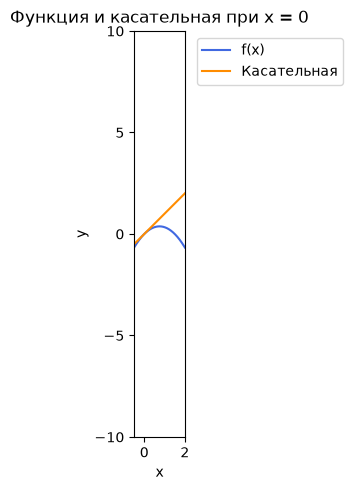

In [122]:
tangent = f(0) + prev*(x-0)
plot_expressions = (f(x),tangent)
plot_labels = ['f(x)', 'Касательная']
plot_title = 'Функция и касательная при x = 0'
prev = sp.plot(*plot_expressions, (x, -0.5, 2),
    xlim=(-0.5, 2), ylim=(-10, 10), title=plot_title, legend=True,
    xlabel="x", ylabel="y", axis_center=None, size=(8, 5), show=False)
for series, label, color in zip(prev, plot_labels, ["royalblue", "darkorange"]):
    series.label = label
    series.line_color = color
prev.process_series()
for spine in prev.ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_position(("outward", 0))
prev.ax.set_xlabel("x", loc="center")
prev.ax.set_ylabel("y", loc="center")
prev.ax.set_aspect("equal", adjustable="box")
prev.ax.set_yticks([-10, -5, 0, 5, 10])
prev.ax.legend(loc="upper left", bbox_to_anchor=(1.1, 1))
prev.fig.tight_layout()
display(prev.fig)
plt.close(prev.fig)

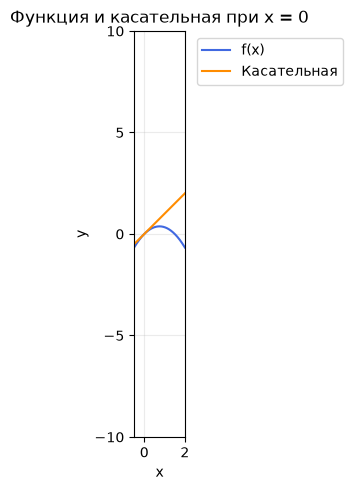

In [123]:
grid = np.linspace(-0.5, 2, 1601)
fig = plt.figure(figsize=(8, 5))
for expression, label, color in zip(plot_expressions, plot_labels, ["royalblue", "darkorange"]):
    numerical = sp.lambdify(x, expression, "numpy")
    plt.plot(grid, np.broadcast_to(numerical(grid), grid.shape), label=label, color=color)
plt.xlim(-0.5, 2)
plt.ylim(-10, 10)
plt.xlabel("x")
plt.ylabel("y")
plt.title(plot_title)
plt.legend(loc="upper left", bbox_to_anchor=(1.1, 1))
plt.grid(True, alpha=0.25)
plt.gca().set_aspect("equal", adjustable="box")
plt.yticks([-10, -5, 0, 5, 10])
plt.tight_layout()
prev = fig
plt.show()

**Maple:** `intercept(y=f(x),y=0);`

Пересечения с осью x: решаем f(x)=0 и возвращаем обе координаты.

In [124]:
prev = tuple({x:root, sp.Symbol("y"):sp.Integer(0)} for root in sp.solve(sp.Eq(f(x),0),x))
display(prev)

({x: 0, y: 0}, {x: 3/2, y: 0})

### Метод средних прямоугольников

Для `middlebox` достаточно Matplotlib. В первом графике исходного PDF четыре прямоугольника, поэтому значение по умолчанию — 4. Высота каждого прямоугольника вычисляется в середине его основания.

In [125]:
def middlebox(expression, variable, left, right, count=4):
    edges = np.linspace(float(left), float(right), count+1)
    midpoints = (edges[:-1]+edges[1:])/2
    numerical = sp.lambdify(variable, expression, "numpy")
    grid = np.linspace(float(left), float(right), 1001)
    fig = plt.figure(figsize=(8,4.8))
    plt.bar(edges[:-1], numerical(midpoints), width=np.diff(edges), align="edge",
            color="#b3dfb2", edgecolor="black", label="Средние прямоугольники")
    plt.plot(grid,numerical(grid),color="red",linewidth=2,label="f(x)")
    plt.xlim(float(left),float(right))
    plt.xlabel(str(variable))
    plt.ylabel("y")
    plt.title(f"Метод средних прямоугольников: n = {count}")
    plt.legend()
    plt.tight_layout()
    plt.show()
    return fig

**Maple:** `middlebox(f(x),x=0..3/2);`

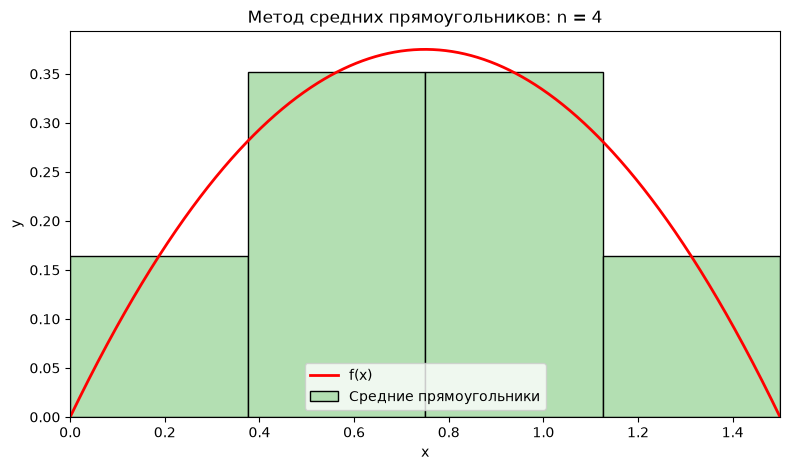

In [126]:
prev = middlebox(f(x),x,0,sp.Rational(3,2))

**Maple:** `middlebox(f(x),x=0..3/2,10);`

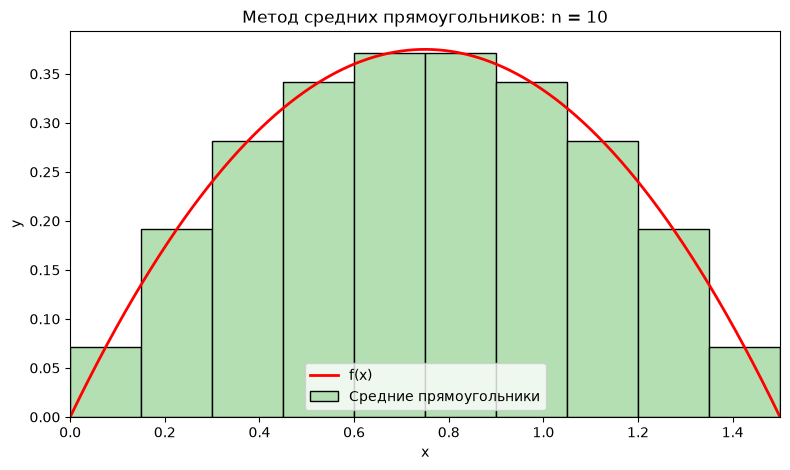

In [127]:
prev = middlebox(f(x),x,0,sp.Rational(3,2),10)

### Символическая сумма и переход к интегралу

`middlesum` возвращает невычисленную `Sum`. Число разбиений `n` — положительное целое; все границы и шаги остаются точными.

In [128]:
n = sp.Symbol("n", integer=True, positive=True)
i = sp.Symbol("i", integer=True)

def middlesum(expression, variable, left, right, count):
    width = (sp.sympify(right)-left)/count
    midpoint = left+(i+sp.Rational(1,2))*width
    return sp.Sum(expression.subs(variable,midpoint)*width,(i,0,count-1))

**Maple:** `middlesum(f(x),x=0..3/2,10);`

In [129]:
prev = middlesum(f(x),x,0,sp.Rational(3,2),10)
display(prev)

  9                            
_____                          
╲                              
 ╲    ⎛                2      ⎞
  ╲   ⎜      ⎛3⋅i   3 ⎞       ⎟
   ╲  ⎜      ⎜─── + ──⎟       ⎟
   ╱  ⎜9⋅i   ⎝20    40⎠     9 ⎟
  ╱   ⎜─── - ─────────── + ───⎟
 ╱    ⎝400       10        800⎠
╱                              
‾‾‾‾‾                          
i = 0                          

**Maple:** `value(%);`

In [130]:
prev = prev.doit()
display(prev)

603 
────
1600

**Maple:** `evalf(%);`

In [131]:
prev = sp.N(prev,Digits)
display(prev)

0.3768750000

**Maple:** `middlesum(f(x),x=0..3/2,n);`

In [132]:
prev = middlesum(f(x),x,0,sp.Rational(3,2),n)
display(prev)

n - 1                                
______                               
╲                                    
 ╲                                   
  ╲      ⎛                         2⎞
   ╲     ⎜3⋅(i + 1/2)   3⋅(i + 1/2) ⎟
    ╲  3⋅⎜─────────── - ────────────⎟
    ╱    ⎜    2⋅n              2    ⎟
   ╱     ⎝                  2⋅n     ⎠
  ╱    ──────────────────────────────
 ╱                  2⋅n              
╱                                    
‾‾‾‾‾‾                               
i = 0                                

**Maple:** `Limit(%,n=infinity);`

In [133]:
prev = sp.Limit(prev,n,sp.oo)
display(prev)

    n - 1                                
    ______                               
    ╲                                    
     ╲                                   
      ╲      ⎛                         2⎞
       ╲     ⎜3⋅(i + 1/2)   3⋅(i + 1/2) ⎟
        ╲  3⋅⎜─────────── - ────────────⎟
lim     ╱    ⎜    2⋅n              2    ⎟
n─→∞   ╱     ⎝                  2⋅n     ⎠
      ╱    ──────────────────────────────
     ╱                  2⋅n              
    ╱                                    
    ‾‾‾‾‾‾                               
    i = 0                                

**Maple:** `value(%);`

In [134]:
prev = prev.doit()
display(prev)

3/8

**Maple:** `evalf(%);`

In [135]:
prev = sp.N(prev,Digits)
display(prev)

0.3750000000

**Maple:** `Int(f(x),x=0..3/2);`

In [136]:
prev = sp.Integral(f(x),(x,0,sp.Rational(3,2)))
display(prev)

3/2                
 ⌠                 
 ⎮  ⎛     2    ⎞   
 ⎮  ⎜  2⋅x     ⎟   
 ⎮  ⎜- ──── + x⎟ dx
 ⎮  ⎝   3      ⎠   
 ⌡                 
 0                 

**Maple:** `value(%);`

In [137]:
prev = prev.doit()
display(prev)

3/8

Сумма при n=10 равна 603/1600 = 0.376875; её предел и определённый интеграл равны 3/8 = 0.375. Метод средних прямоугольников сходится к площади под графиком.

### Просмотр реализации процедуры

**Maple:** `interface(verboseproc=2);` → `eval(middlebox);` → `interface(verboseproc=1);`

Эти команды временно включают подробный вывод реализации процедуры Maple, затем восстанавливают прежний режим. В Jupyter реализация нашей `middlebox` полностью приведена в кодовой ячейке выше. Внутренний код Maple и параметр `verboseproc` не воспроизводятся; это не отдельные математические вычисления.

## Контроль результатов

Следующая ячейка проверяет деление полиномов, решения уравнений, начальные и краевые условия, а также точные суммы и интеграл. Проверки завершаются сообщением только при выполнении всех условий.

In [138]:
assert sp.expand((x**2+x+1)*q+r) == x**3+x+1
assert sp.simplify(ode1.lhs.subs(y_unknown,y1).doit()-ode1.rhs) == 0
assert all(sp.simplify(lhs.subs(y_unknown,y1).doit()-rhs)==0 for lhs,rhs in ic.items())
bvp_function = sp.Lambda(x,bvp_solution.rhs)
assert all(sp.simplify((eq.lhs-eq.rhs).subs(y_unknown,bvp_function).doit())==0 for eq in iv+bc)
assert simplify_deltas((ode2.lhs-ode2.rhs).subs(y_unknown,bvp_function).doit(),x)==0
system_solution = {eq.lhs:eq.rhs for eq in soln}
assert all(sp.simplify((eq.lhs-eq.rhs).subs(system_solution,simultaneous=True).doit())==0 for eq in de_sys)
assert middlesum(f(x),x,0,sp.Rational(3,2),10).doit() == sp.Rational(603,1600)
sum_formula = sp.simplify(middlesum(f(x),x,0,sp.Rational(3,2),n).doit())
assert sp.limit(sum_formula,n,sp.oo) == sp.integrate(f(x),(x,0,sp.Rational(3,2))) == sp.Rational(3,8)
display("Проверки пройдены.")

'Проверки пройдены.'